# OpenBind-HIPPO

- **Target: A71EV2A**
- **Cycle: 02**

## Imports

In [5]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
from rdkit.Chem import PandasTools
import pandas as pd
import plotly.express as px

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Config

In [6]:
target_name = "A71EV2A"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_02"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [7]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite")
# animal = hippo.HIPPO(target_name, target_dir / f"{target_name}_testing.sqlite")#, copy_from=target_dir / f"{target_name}.sqlite")

 Creating HIPPO animal

name = A71EV2A

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite!

 Success  Initialised animal HIPPO("A71EV2A")!

## Syndirella inputs

Run syndirella on all ASAP structural hits, with self-referential inspiration

In [ ]:
hits = animal.poses(tag="hits")
hits

In [ ]:
hits.to_syndirella("cycle_02/syndirella/elabs/c2_elabs", separate=True)

## Load Syndirella Elabs

Check using below cells and then queue `c02b_load_elabs.py`

In [5]:
output_root = cycle_dir / "syndirella/elabs/"
files = list(output_root.glob("*/*-*-?/*to_hippo*"))
len(files)

334

In [6]:
print(files[0])

cycle_02/syndirella/elabs/c2_elabs_A4489b/UWGHAGSZEJRSBU-UHFFFAOYSA-N/UWGHAGSZEJRSBU-UHFFFAOYSA-N_25f427d90acd2eee5
458aadf6155c2db_to_hippo.pkl.gz

In [40]:
%%time
scaffold = animal.poses["A4489b"].compound
df = animal.add_syndirella_elabs(files[0], scaffold_compound=scaffold, dry_run=False)
df

╭──────────────────────────────────────────────────────────────────────────────╮
│ UWGHAGSZEJRSBU-UHFFFAOYSA-N_25f427d90acd2eee5458aadf6155c2db_to_hippo.pkl.gz │
╰──────────────────────────────────────────────────────────────────────────────╯

 DISK  Reading 
cycle_02/syndirella/elabs/c2_elabs_A4489b/UWGHAGSZEJRSBU-UHFFFAOYSA-N/UWGHAGSZEJRSBU-UHFFFAOYSA-N_25f427d90acd2eee5
458aadf6155c2db_to_hippo.pkl.gz...

num_steps = 1

 Warning  Flags in DataFrame: {'one_of_multiple_products'}!

Filtering out 52 rows from step 1 due to one_of_multiple_products

...

#poses ∆∆G > 0.0 = 464

#poses comRMSD > 2.0 = 476

#acceptable poses = 0

 Warning  No valid poses!

CPU times: user 4.19 s, sys: 8.44 s, total: 12.6 s
Wall time: 1min 38s


## Check Elabs

In [8]:
animal.tags.summary()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ tag                                         ┃ num_compounds ┃ num_poses ┃ num_posed_compounds ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ BAD count                                   │ 0             │ 645       │ 457                 │
│ BulkDock Fragalysis export                  │ 0             │ 1749      │ 1145                │
│ C10 85percent analogue                      │ 31            │ 0         │ 0                   │
│ C10 90percent analogue                      │ 6             │ 0         │ 0                   │
│ C100 85percent analogue                     │ 32            │ 0         │ 0                   │
│ C101 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C102 85percent analogue                     │ 5             │ 0         │ 0                   │
│ C103 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C104 85percent analogue                     │ 19            │ 0         │ 0                   │
│ C105 85percent analogue                     │ 32            │ 0         │ 0                   │
│ C106 85percent analogue                     │ 24            │ 0         │ 0                   │
│ C107 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C108 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C109 85percent analogue                     │ 108           │ 0         │ 0                   │
│ C11 85percent analogue                      │ 11            │ 0         │ 0                   │
│ C11 90percent analogue                      │ 4             │ 0         │ 0                   │
│ C111 85percent analogue                     │ 15            │ 0         │ 0                   │
│ C112 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C113 85percent analogue                     │ 4             │ 0         │ 0                   │
│ C114 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C115 85percent analogue                     │ 129           │ 0         │ 0                   │
│ C116 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C117 85percent analogue                     │ 5             │ 0         │ 0                   │
│ C119 85percent analogue                     │ 6             │ 0         │ 0                   │
│ C12 85percent analogue                      │ 38            │ 0         │ 0                   │
│ C12 90percent analogue                      │ 16            │ 0         │ 0                   │
│ C120 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C121 85percent analogue                     │ 17            │ 0         │ 0                   │
│ C122 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C123 85percent analogue                     │ 12            │ 0         │ 0                   │
│ C127 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C128 85percent analogue                     │ 11            │ 0         │ 0                   │
│ C129 85percent analogue                     │ 26            │ 0         │ 0                   │
│ C13 85percent analogue                      │ 14            │ 0         │ 0                   │
│ C13 90percent analogue                      │ 2             │ 0         │ 0                   │
│ C132 85percent analogue                     │ 10            │ 0         │ 0                   │
│ C136 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C137 85percent analogue                     │ 1             │ 0         │ 0   

In [5]:
hit_elabs = animal.compounds(tag="openbind_a71ev2a_c2_elabs")
hit_elabs

compounds tagged openbind_a71ev2a_c2_elabs: {C × 90420}

In [6]:
hit_elab_poses = animal.poses(tag="openbind_a71ev2a_c2_elabs")
hit_elab_poses

poses tagged "openbind_a71ev2a_c2_elabs": {P × 56412}

In [7]:
elaborated_hits = hit_elabs.scaffolds
elaborated_hits

{C × 167}

In [11]:
posed_elabs = hit_elabs.poses.compounds
posed_elabs

{C × 29807}

In [15]:
hit_elabs.write_smiles_csv("cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elabs.csv")

 DISK  Writing cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elabs.csv...

In [ ]:
hit_elab_poses.to_fragalysis("cycle_01/syndirella/elabs/openbind_a71ev2a_c2_elabs.sdf",
    method="openbind_a71ev2a_c2_elabs", 
    submitter_name="Max Winokan", 
    submitter_institution="DLS", 
    submitter_email="max.winokan@diamond.ac.uk",
    copy_reference_pdbs=True,
    metadata=False,
    tags=False,
    subsites=False,
)

## Routes to scaffolds

1. Export list of elaborated hits
2. Run syndirella just retro
3. Load routes back into HIPPO

In [22]:
elaborated_hit_poses = elaborated_hits.poses(tag="hits")
elaborated_hit_poses

{P × 247}

In [23]:
elaborated_hit_poses.to_syndirella("cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits")

out_key = openbind_a71ev2a_c2_elaborated_hits

#poses = 247

DEBUG: querying...

Output()

DEBUG: adding inspiration column(s)

...

 DISK  Writing cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits_syndirella_input.csv...

DEBUG: querying...

Output()

 DISK  Writing 
cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits_syndirella_inspiration_hits.sdf...

,smiles,template,compound_set,hit1
id,,,,
4,NC(=O)[C@H]1CCCN(C(=O)Cc2cccc3c2SCC3)C1,A5151a,openbind_a71ev2a_c2_elaborated_hits,A5151a
6,CNC(=O)c1cn(C)c2ccccc12,A0451a,openbind_a71ev2a_c2_elaborated_hits,A0451a
15,COc1ccc2sc(N)nc2c1,A0514a,openbind_a71ev2a_c2_elaborated_hits,A0514a
16,COc1ccc2sc(N)nc2c1,A0514b,openbind_a71ev2a_c2_elaborated_hits,A0514b
19,CCn1cc(C(=O)NCc2ccc(F)cc2)cn1,A0517a,openbind_a71ev2a_c2_elaborated_hits,A0517a
...,...,...,...,...
606,CSc1ccc(Br)cc1CC(=O)N1C[C@@H](C(N)=O)CC[C@H]1C,A5366a,openbind_a71ev2a_c2_elaborated_hits,A5366a
607,CSc1ccc(Br)cc1CC(=O)N1C[C@@H](C(N)=O)CC[C@H]1C,A5366b,openbind_a71ev2a_c2_elaborated_hits,A5366b
609,CSc1ccc(Br)cc1CC(=O)N1CC[C@](O)(C(N)=O)C1,A5388a,openbind_a71ev2a_c2_elaborated_hits,A5388a


In [29]:
animal.add_syndirella_routes(
    "cycle_02/syndirella/retrosynthesis/justretroquery_openbind_a71ev2a_c2_elaborated_hits_syndirella_input.pkl.gz", 
    CAR_only=False,
    check_chemistry=False,
)

Output()

0 0 0 Amidation C4 "ASAP-0038158-001"

 Success  registered route 20380!

1 0 0 Amidation C6 "ASAP-0018935-002"

 Success  registered route 20381!

...

405 0 0 Buchwald-Hartwig_amination C454 "ASAP-0039147-001"

 Success  registered route 20785!

406 0 0 Buchwald-Hartwig_amination C454 "ASAP-0039147-001"

 Success  registered route 20786!

,smiles,template,compound_set,hit1,route0,route0_names,route0_CAR,route0_non_CAR,route1,route1_names,...,route2_CAR,route2_non_CAR,route3,route3_names,route3_CAR,route3_non_CAR,route4,route4_names,route4_CAR,route4_non_CAR
0,NC(=O)[C@H]1CCCN(C(=O)Cc2cccc3c2SCC3)C1,A5151a,openbind_a71ev2a_c2_elaborated_hits,A5151a,"[{'name': 'Amidation', 'reactantSmiles': ['O=C...",[Amidation],True,None,"[{'name': 'Alpha-arylation', 'reactantSmiles':...",[Alpha-arylation],...,False,[Alpha-arylation],"[{'name': 'Ester_amidation', 'reactantSmiles':...",[Ester_amidation],True,None,"[{'name': 'Ester_amidation', 'reactantSmiles':...",[Ester_amidation],True,None
1,CNC(=O)c1cn(C)c2ccccc12,A0451a,openbind_a71ev2a_c2_elaborated_hits,A0451a,"[{'name': 'Amidation', 'reactantSmiles': ['Cn1...",[Amidation],True,None,"[{'name': 'Amine_alkylation', 'reactantSmiles'...",[Amine_alkylation],...,False,"[Chan-Lam_coupling_of_amides,_sulfonamides,_an...",[{'name': 'Mitsunobu_reaction_with_aromatic_nh...,[Mitsunobu_reaction_with_aromatic_nh],False,[Mitsunobu_reaction_with_aromatic_nh],"[{'name': 'Amide_Schotten-Baumann_with_amine',...",[Amide_Schotten-Baumann_with_amine],True,None
2,CNC(=O)c1cn(C)c2ccccc12,A0451a,openbind_a71ev2a_c2_elaborated_hits,A0451a,"[{'name': 'Amidation', 'reactantSmiles': ['Cn1...",[Amidation],True,None,"[{'name': 'Amine_alkylation', 'reactantSmiles'...",[Amine_alkylation],...,False,"[Chan-Lam_coupling_of_amides,_sulfonamides,_an...",[{'name': 'Mitsunobu_reaction_with_aromatic_nh...,[Mitsunobu_reaction_with_aromatic_nh],False,[Mitsunobu_reaction_with_aromatic_nh],"[{'name': 'Amide_Schotten-Baumann_with_amine',...",[Amide_Schotten-Baumann_with_amine],True,None
3,COc1ccc2sc(N)nc2c1,A0514a,openbind_a71ev2a_c2_elaborated_hits,A0514a,[{'name': 'N-nucleophilic_aromatic_substitutio...,[N-nucleophilic_aromatic_substitution],True,None,[{'name': 'O-Nucleophilic_aromatic_substitutio...,[O-Nucleophilic_aromatic_substitution_(methyls...,...,True,None,[{'name': 'N-nucleophilic_aromatic_substitutio...,[N-nucleophilic_aromatic_substitution],True,None,[{'name': 'N-nucleophilic_aromatic_substitutio...,[N-nucleophilic_aromatic_substitution],True,None
4,COc1ccc2sc(N)nc2c1,A0514a,openbind_a71ev2a_c2_elaborated_hits,A0514a,[{'name': 'N-nucleophilic_aromatic_substitutio...,[N-nucleophilic_aromatic_substitution],True,None,[{'name': 'O-Nucleophilic_aromatic_substitutio...,[O-Nucleophilic_aromatic_substitution_(methyls...,...,True,None,[{'name': 'N-nucleophilic_aromatic_substitutio...,[N-nucleophilic_aromatic_substitution],True,None,[{'name': 'N-nucleophilic_aromatic_substitutio...,[N-nucleophilic_aromatic_substitution],True,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,CSc1ccc(Br)cc1CC(=O)N1CC[C@](O)(C(N)=O)C1,A5388a,openbind_a71ev2a_c2_elaborated_hits,A5388a,"[{'name': 'Amidation', 'reactantSmiles': ['NC(...",[Amidation],True,None,[{'name': 'S-nucleophilic_aromatic_substitutio...,[S-nucleophilic_aromatic_substitution],...,True,None,[{'name': 'S-nucleophilic_aromatic_substitutio...,[S-nucleophilic_aromatic_substitution],True,None,[{'name': 'Sp3-sp2_Macmillan_coupling_alcohol_...,[Sp3-sp2_Macmillan_coupling_alcohol_and_aryl_h...,False,[Sp3-sp2_Macmillan_coupling_alcohol_and_aryl_h...
403,CSc1ccc(N2CCOCC2)cc1NC(=O)N1CCC[C@H](C(N)=O)C1,A5598a,openbind_a71ev2a_c2_elaborated_hits,A5598a,"[{'name': 'Buchwald-Hartwig_amination', 'react...",[Buchwald-Hartwig_amination],True,None,"[{'name': 'Buchwald-Hartwig_amination', 'react...",[Buchwald-Hartwig_amination],...,True,None,"[{'name': 'Iodo_N-arylation', 'reactantSmiles'...","[Iodo_N-arylation, Buchwald-Hartwig_amination]",True,None,[{'name': 'Mitsunobu_reaction_with_amine_alcoh...,[Mitsunobu_reaction_with_amine_alcohol_and_thi...,True,None
404,CSc1ccc(N2CCOCC2)cc1NC(=O)N1CCC[C@H](C(N)=O)C1,A5598a,openbind_a71ev2a_c2_elaborated_hits,A5598a,"[{'name': 'Buchwald-Hartwig_amination', 'react...",[Buchwald-Hartwig_amination],True,None,"[{'name': 'Buchwald-Hartwig_amination', 'react

In [30]:
animal.db.prune_duplicate_routes()

#routes = 20231

products with duplicate routes = 65

compound 107 has 2 duplicate routes

compound 6 has 4 duplicate routes

compound 14 has 4 duplicate routes

...

compound 426 has 4 duplicate routes

compound 430 has 4 duplicate routes

compound 454 has 4 duplicate routes

 Success  Deleted 246 duplicate routes!

{20382,
 20384,
 20385,
 20386,
 20390,
 20391,
 20392,
 20395,
 20396,
 20397,
 20404,
 20405,
 20406,
 20412,
 20413,
 20414,
 20415,
 20416,
 20417,
 20418,
 20419,
 20421,
 20422,
 20423,
 20427,
 20435,
 20436,
 20437,
 20439,
 20440,
 20444,
 20445,
 20446,
 20448,
 20449,
 20450,
 20451,
 20452,
 20455,
 20456,
 20461,
 20467,
 20473,
 20474,
 20477,
 20478,
 20479,
 20482,
 20483,
 20484,
 20486,
 20487,
 20489,
 20490,
 20491,
 20492,
 20493,
 20495,
 20497,
 20498,
 20499,
 20500,
 20501,
 20502,
 20505,
 20506,
 20510,
 20511,
 20512,
 20513,
 20514,
 20515,
 20516,
 20520,
 20521,
 20522,
 20524,
 20528,
 20529,
 20530,
 20536,
 20537,
 20538,
 20540,
 20541,
 20542,
 20545,
 20546,
 20547,
 20550,
 20551,
 20552,
 20554,
 20555,
 20556,
 20559,
 20560,
 20561,
 20569,
 20570,
 20571,
 20572,
 20573,
 20575,
 20576,
 20577,
 20581,
 20582,
 20583,
 20589,
 20590,
 20591,
 20592,
 20593,
 20594,
 20595,
 20597,
 20598,
 20599,
 20601,
 20602,
 20603,
 20609,
 20610,
 20611,


In [31]:
print(elaborated_hits)
hit_elab_routes = hippo.RouteSet.from_product_ids(animal.db, elaborated_hits.ids)
hit_elab_routes

{C × 167}

Output()

{Route × 167}

In [32]:
recipes = hippo.Recipe.from_compounds(elaborated_hits, use_routes=True, pick_cheapest=False)
len(recipes)

#compounds = 167

Output()

 Success  Found solution for compound=C4!

 Success  Found solution for compound=C6!

 Success  Found solution for compound=C14!

...

 Success  Found solution for compound=C205775!

 Success  Found solution for compound=C266892!

Solving recipe combinations...

Output()

1

In [33]:
recipe = recipes[0]
recipe.write_json("cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits_recipe.json")

 Warning  NULL Quote: 1.00mg of C375990!

 Warning  NULL Quote: 2.00mg of C282937!

 Warning  NULL Quote: 2.00mg of C327588!

 Warning  NULL Quote: 5.00mg of C282920!

 Warning  NULL Quote: 1.00mg of C443752!

...

 Warning  NULL Quote: 1.00mg of C319845!

 Warning  NULL Quote: 1.00mg of C141!

 Warning  NULL Quote: 1.00mg of C329353!

 Warning  NULL Quote: 1.00mg of C182944!

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elabor
ated_hits_recipe.json...

In [34]:
recipe.write_CAR_csv("cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits_recipe_CAR.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

Output()

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elabor
ated_hits_recipe_CAR_1steps.csv...

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elabor
ated_hits_recipe_CAR.csv...

,target-names,no-steps,concentration-required-mM,amount-required-uL,batch-tag,reactant-1-1,reactant-2-1,reaction-product-smiles-1,reaction-name-1,reaction-recipe-1,reaction-groupby-column-1,reactant-3-1
0,C176,1,None,None,None,Cn1cc2c(CC(=O)O)cccc2n1,NC(=O)C1CCNC1,Cn1cc2c(CC(=O)N3CCC(C(N)=O)C3)cccc2n1,Amidation,None,None,<NA>
1,C180,1,None,None,None,NC(=O)C1CCCCNC1,COc1ccccc1CC(=O)O,COc1ccccc1CC(=O)N1CCCCC(C(N)=O)C1,Amidation,None,None,<NA>
2,C181,1,None,None,None,NC(=O)C1CCCNC1,COc1c(C#N)cccc1CC(=O)O,COc1c(C#N)cccc1CC(=O)N1CCCC(C(N)=O)C1,Amidation,None,None,<NA>
3,C182,1,None,None,None,NC(=O)C1CCCNC1,COc1cccc(Cl)c1CC(=O)O,COc1cccc(Cl)c1CC(=O)N1CCCC(C(N)=O)C1,Amidation,None,None,<NA>
4,C185,1,None,None,None,NC(=O)C1CCCNC1,COc1ccccc1C(OC)C(=O)O,COc1ccccc1C(OC)C(=O)N1CCCC(C(N)=O)C1,Amidation,None,None,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
162,C149,1,None,None,None,NCCc1cocn1,Cn1nc(C(=O)O)c2ccccc2c1=O,Cn1nc(C(=O)NCCc2cocn2)c2ccccc2c1=O,Amidation,None,None,<NA>
163,C150,1,None,None,None,NCCc1cocn1,O=C(O)c1ccccc1,O=C(NCCc1cocn1)c1ccccc1,Amidation,None,None,<NA>
164,C151,1,None,None,None,NCCc1cocn1,Cn1ncc(C(=O)O)n1,Cn1ncc(C(=O)NCCc2cocn2)n1,Amidation,None,None,<NA>
165,C160,1,None,None,None,NC(=O)C1CCCNC1,Cn1ncc(-c2cc(Cl)cc(Cl)c2)c1CC(=O)O,Cn1ncc(-c2cc(Cl)cc(Cl)c2)c1CC(=O)N1CCCC(C(N)=O)C1,Amidation,None,None,<NA>


In [35]:
recipe.write_reactant_csv("cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits_recipe_reactants.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

 DISK  Writing cycle_02/syndirella/retrosynthesis/openbind_a71ev2a_c2_elaborated_hits_recipe_reactants.csv...

## Reactants needed for full elabs

1. Quote reactatns
1. Needs route enumeration first

In [37]:
bbdb = hippo.HIPPO("BB", "../../EnamineCatalogs/enamine_bb_hippo.sqlite")

 Creating HIPPO animal

name = BB

db_path = ../../EnamineCatalogs/enamine_bb_hippo.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = ../../EnamineCatalogs/enamine_bb_hippo.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ ../../EnamineCatalogs/enamine_bb_hippo.sqlite!

 Success  Initialised animal HIPPO("BB")!

In [38]:
animal.quote_reactants(bbdb)

#compounds = 18391

Output()

 Warning  Isotope(s) in SMILES: [2H]c1c([2H])c([2H])c([CH]2C[CH]2N)c([2H])c1[2H]!

 Warning  Isotope(s) in SMILES: [2H]c1c([2H])c([2H])c([CH]2C[CH]2N)c([2H])c1[2H]!

 Warning  Isotope(s) in SMILES: [2H]c1c([2H])c([2H])c([CH]2C[CH]2N)c([2H])c1[2H]!

...

 Warning  Isotope(s) in SMILES: [2H]C([2H])([2H])OS(C)(=O)=O!

 Warning  Isotope(s) in SMILES: [2H]C([2H])([2H])OS(C)(=O)=O!

#new quotes = 111344

#quoted_compounds = 17625

#unquoted_compounds = 766

In [42]:
hit_elabs = animal.compounds(tag="openbind_a71ev2a_c2_elabs")
hit_elabs

compounds tagged openbind_a71ev2a_c2_elabs: {C × 90420}

In [43]:
routes = hippo.RouteSet.from_product_ids(animal.db, (hit_elabs.scaffolds + hit_elabs).ids)
routes

Output()

{Route × 85229}

In [44]:
routes.reactants

{C × 6872}

In [45]:
routes.reactants.write_smiles_csv("cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elab_route_reactants.csv")

 DISK  Writing cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elab_route_reactants.csv...

## Export all elabs

In [46]:
!python -m zipfile -c cycle_02/syndirella/elabs/templates.zip cycle_02/syndirella/elabs/templates/*.pdb

In [47]:
!python -m zipfile -c cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elabs_poses.zip cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elabs_???????.sdf

## Load GNINA scores

In [4]:
ref_sdf = "cycle_02/syndirella/elabs/openbind_a71ev2a_c2_elabs_1LSYIDY.sdf"
pdf = PandasTools.LoadSDF(ref_sdf)
pdf = pdf[["HIPPO Pose ID", "ID"]].rename(columns={"HIPPO Pose ID":"id", "ID":"name"}).iloc[1:].set_index("name")
pdf.head()

,id
name,
P534287,534287
P534288,534288
P534290,534290
P534291,534291
P534292,534292


In [5]:
sdf = pd.read_csv("cycle_02/gnina/openbind_a71ev2a_c2_elabs_1LSYIDY_scores.csv")
sdf.head()

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd
0,P534287,5.477,5.610,-6.226,0.773
1,P534288,6.147,5.939,-6.927,1.113
2,P534290,5.218,5.128,-5.535,0.637
3,P534291,5.582,5.402,-5.661,0.634
4,P534292,5.370,5.191,-6.257,0.721


In [6]:
sdf["pose_id"] = sdf["name"].apply(lambda x: int(pdf.loc[x, "id"]))
sdf = sdf.set_index("pose_id")
sdf

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd
pose_id,,,,,
534287,P534287,5.477,5.610,-6.226,0.773
534288,P534288,6.147,5.939,-6.927,1.113
534290,P534290,5.218,5.128,-5.535,0.637
534291,P534291,5.582,5.402,-5.661,0.634
534292,P534292,5.370,5.191,-6.257,0.721
...,...,...,...,...,...
590693,P590693,3.785,3.962,-3.118,1.521
590694,P590694,3.856,3.545,-2.648,0.769
590695,P590695,3.924,4.052,-3.260,1.571


In [7]:
%%time
pose_ids = set()
for i,row in sdf.iterrows():
    pose = animal.poses[i]
    metadata = pose.metadata
    metadata.update({
        "gnina_score":row["gnina_score"],
        "gnina_score_min":row["gnina_score_min"],
        "smina_score_min":row["smina_score_min"],
        "rmsd(smina/fragmenstein)":row["min_rmsd"],
    })
    pose_ids.add(i)
    # break
scored_poses = animal.poses[pose_ids]
scored_poses.add_tag("openbind_a71ev2a_c2_elabs_scored")

Tagged {P × 29658} w/ "openbind_a71ev2a_c2_elabs_scored"

CPU times: user 10.7 s, sys: 28.4 s, total: 39.2 s
Wall time: 16min 9s


## GNINA score distributions

In [8]:
scored_poses = animal.poses(tag="openbind_a71ev2a_c2_elabs_scored")
scored_poses

poses tagged "openbind_a71ev2a_c2_elabs_scored": {P × 29658}

In [9]:
%%time
data = []
for pose in scored_poses:
    metadata = pose.metadata
    data.append({
        "pose_id":pose.id, 
        "gnina_score":metadata["gnina_score"],
        "gnina_score_min":metadata["gnina_score_min"],
        "smina_score_min":metadata["smina_score_min"],
        "rmsd(smina/fragmenstein)":metadata["rmsd(smina/fragmenstein)"],
    })
df = pd.DataFrame(data)

CPU times: user 4.86 s, sys: 11 s, total: 15.9 s
Wall time: 3min 6s


In [23]:
score_cutoff = df["gnina_score_min"].quantile(0.20)
score_cutoff = 6
score_cutoff

6

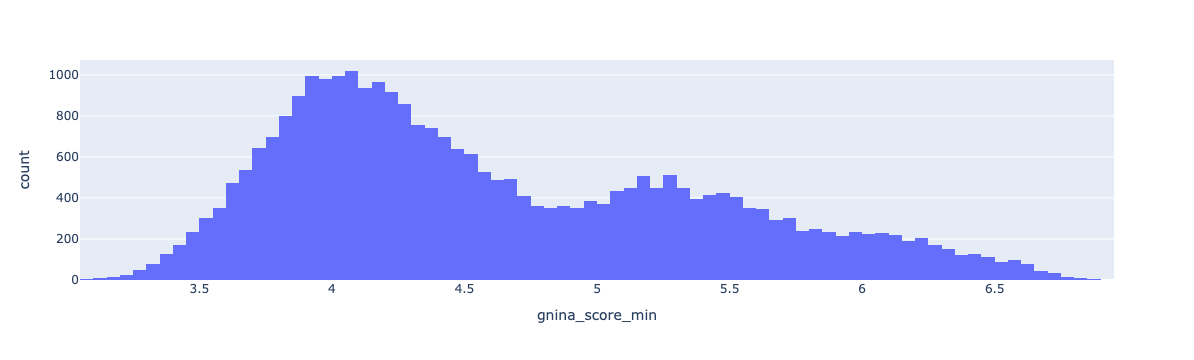

In [13]:
px.histogram(df, x="gnina_score_min")

In [24]:
filtered_scored_ids = df[df["gnina_score_min"] >= score_cutoff]["pose_id"].unique()

In [25]:
filtered_scored_poses = animal.poses[filtered_scored_ids]
filtered_scored_poses

{P × 2126}

In [26]:
filtered_scored_poses.compounds

{C × 2126}

In [27]:
filtered_scored_poses.add_tag("openbind_a71ev2a_c2_elabs_scored_6plus")
filtered_scored_poses.compounds.add_tag("openbind_a71ev2a_c2_elabs_scored_6plus")

Tagged {P × 2126} w/ "openbind_a71ev2a_c2_elabs_scored_6plus"

Tagged {C × 2126} w/ "openbind_a71ev2a_c2_elabs_scored_6plus"

## get combined BB quote

In [18]:
q = animal.add_enamine_quote(
    "../combined/Q2142596_2025-12(dec)-01-Single hit enumeration building blocks(Syndirella).xlsx",
    orig_name_col = "HIPPO Compound ID (a71ev2a)",
    smiles_col = "smiles",
    entry_col = "Enamine ID",
    fixed_amount = 1,
    price_col = "Price, EUR (1mg)",
    fixed_purity = None,
    fixed_lead_time = None,
    dry_run = False,
    currency = "EUR",
    allow_no_catalogue_col = True,
    orig_name_is_hippo_id=True,
    warn_nan_orig_name = False,
    overwrite_existing_quotes=False,
    delete_unavailable = False,
    debug = False,
)
q

Output()

 Warning  SMILES changed during compound registration: [CH3][Mg][I] --> C[Mg]I!

 Warning  SMILES changed during compound registration: O=C(CCl)Nc1cc[nH]n1 --> O=C(CCl)Nc1ccn[nH]1!

 Warning  SMILES changed during compound registration: COc1cc(N)n[nH]1 --> COc1cc(N)[nH]n1!

{Ingredient × 6179}

In [19]:
q = animal.add_enamine_quote(
    "../combined/Q2142596_2025-12(dec)-01-Single hit enumeration building blocks(Syndirella).xlsx",
    orig_name_col = "HIPPO Compound ID (a71ev2a)",
    smiles_col = "smiles",
    entry_col = "Enamine ID",
    fixed_amount = 10,
    price_col = "Price, EUR (10mg)",
    fixed_purity = None,
    fixed_lead_time = None,
    dry_run = False,
    currency = "EUR",
    allow_no_catalogue_col = True,
    orig_name_is_hippo_id=True,
    warn_nan_orig_name = False,
    overwrite_existing_quotes=False,
    delete_unavailable = False,
    debug = False,
)
q

Output()

 Warning  SMILES changed during compound registration: [CH3][Mg][I] --> C[Mg]I!

 Warning  SMILES changed during compound registration: O=C(CCl)Nc1cc[nH]n1 --> O=C(CCl)Nc1ccn[nH]1!

 Warning  SMILES changed during compound registration: COc1cc(N)n[nH]1 --> COc1cc(N)[nH]n1!

{Ingredient × 6167}

## Filter based on GNINA scores

In [28]:
%%time
recipe = hippo.Recipe.from_compounds(
    filtered_scored_poses.compounds, 
    # supplier="Enamine", 
    pick_cheapest=True,
    # use_routes=True,
    quoted_only=True,
    use_routes=False,
)
recipe

#compounds = 2126

Output()

 ERROR  Reactants not available for reaction=R20290: C315626 + C315633 -> C315683 via 
Ester_amidation!

 ERROR  No solutions for compound=C315683 (comp.reactions.ids=[20290])!

 ERROR  Reactants not available for reaction=R21846: C300648 + C317772 -> C317913 via Amidation!

...

DEBUG: No quote available for C283201 with amount >= 34.0 mg. Estimating price...

DEBUG: No quote available for C412605 with amount >= 5.0 mg. Estimating price...

DEBUG: No quote available for C412649 with amount >= 4.0 mg. Estimating price...

CPU times: user 2min 32s, sys: 2min 10s, total: 4min 43s
Wall time: 37min 17s


Recipe({Ingredient × 784} --> {Ingredient × 1844} via {R × 1844})

In [10]:
# recipe.write_json("cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_recipe.json")
recipe = hippo.Recipe.from_json(animal.db, "cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_recipe.json")

 DISK  Reading cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_recipe.json...

Recipe was generated at: 2025-12-09 12:13:49.159157

reactants = {Ingredient × 784}

intermediates = {Ingredient × 0}

products = {Ingredient × 1844}

reactions = {R × 1844}

compounds = {Ingredient × 0}

In [13]:
recipe.calculate_missing_routes()

#products = 0

Output()

#routes = 105858

products with duplicate routes = 987

compound 191887 has 2 duplicate routes

...

compound 415063 has 2 duplicate routes

compound 415064 has 2 duplicate routes

compound 415066 has 2 duplicate routes

compound 415067 has 2 duplicate routes

 Success  Deleted 987 duplicate routes!

In [11]:
recipe.write_reactant_csv("cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_reactants.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

DEBUG: No quote available for C282946 with amount >= 403.0 mg. Estimating price...

DEBUG: No quote available for C282967 with amount >= 16.0 mg. Estimating price...

...

DEBUG: No quote available for C315421 with amount >= 12.0 mg. Estimating price...

DEBUG: No quote available for C283201 with amount >= 34.0 mg. Estimating price...

DEBUG: No quote available for C412605 with amount >= 5.0 mg. Estimating price...

DEBUG: No quote available for C412649 with amount >= 4.0 mg. Estimating price...

 DISK  Writing cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_reactants.csv...

In [14]:
recipe.write_CAR_csv("cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_CAR.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

Output()

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_CAR_1st
eps.csv...

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_02/gnina/openbind_a71ev2a_c2_elabs_scored_6plus_CAR.csv
...

,target-names,no-steps,concentration-required-mM,amount-required-uL,batch-tag,reactant-1-1,reactant-2-1,reaction-product-smiles-1,reaction-name-1,reaction-recipe-1,reaction-groupby-column-1
0,C417966,1,None,None,None,Cn1nc(C(=O)O)c2cc(Br)ccc21,CCc1nc(CN)c[nH]1,CCc1nc(CNC(=O)c2nn(C)c3ccc(Br)cc23)c[nH]1,Amidation,None,None
1,C417967,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,CC(N)c1cncn1C,CC(NC(=O)c1nn(C)c2ccc(F)cc12)c1cncn1C,Amidation,None,None
2,C417970,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,CCc1nc(CN)c[nH]1,CCc1nc(CNC(=O)c2nn(C)c3ccc(F)cc23)c[nH]1,Amidation,None,None
3,C417973,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,C=CC(N)c1c[nH]cn1,C=CC(NC(=O)c1nn(C)c2ccc(F)cc12)c1c[nH]cn1,Amidation,None,None
4,C417974,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,Cc1nc(CN)c(C)[nH]1,Cc1nc(CNC(=O)c2nn(C)c3ccc(F)cc23)c(C)[nH]1,Amidation,None,None
...,...,...,...,...,...,...,...,...,...,...,...
1839,C417954,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,CC(N)c1c[nH]cn1,CC(NC(=O)c1nn(C)c2ccc(F)cc12)c1c[nH]cn1,Amidation,None,None
1840,C417955,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,Cc1[nH]cnc1CN,Cc1[nH]cnc1CNC(=O)c1nn(C)c2ccc(F)cc12,Amidation,None,None
1841,C417956,1,None,None,None,Cn1nc(C(=O)O)c2cc(F)ccc21,Cn1cnc(CN)c1,Cn1cnc(CNC(=O)c2nn(C)c3ccc(F)cc23)c1,Amidation,None,None
1842,C417963,1,None,None,None,Cn1nc(C(=O)O)c2cc(Br)ccc21,Cc1nc(CN)c(C)[nH]1,Cc1nc(CNC(=O)c2nn(C)c3ccc(Br)cc23)c(C)[nH]1,Amidation,None,None


In [33]:
recipe.price

DEBUG: No quote available for C282946 with amount >= 403.0 mg. Estimating price...

DEBUG: No quote available for C282967 with amount >= 16.0 mg. Estimating price...

DEBUG: No quote available for C282956 with amount >= 13.0 mg. Estimating price...

DEBUG: No quote available for C289813 with amount >= 13.0 mg. Estimating price...

DEBUG: No quote available for C289805 with amount >= 377.0 mg. Estimating price...

...

DEBUG: No quote available for C315421 with amount >= 12.0 mg. Estimating price...

DEBUG: No quote available for C283201 with amount >= 34.0 mg. Estimating price...

DEBUG: No quote available for C412605 with amount >= 5.0 mg. Estimating price...

DEBUG: No quote available for C412649 with amount >= 4.0 mg. Estimating price...

€68653.00 EUR

## Crystal Hit Analogues

Queue `c02c_hit_analogues.py`

In [16]:
animal.tags.summary()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ tag                                         ┃ num_compounds ┃ num_poses ┃ num_posed_compounds ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ BAD count                                   │ 0             │ 645       │ 457                 │
│ BulkDock Fragalysis export                  │ 0             │ 1749      │ 1145                │
│ C10 85percent analogue                      │ 31            │ 0         │ 0                   │
│ C10 90percent analogue                      │ 6             │ 0         │ 0                   │
│ C10 95percent analogue                      │ 1             │ 0         │ 0                   │
│ C100 85percent analogue                     │ 32            │ 0         │ 0                   │
│ C100 90percent analogue                     │ 8             │ 0         │ 0                   │
│ C100 95percent analogue                     │ 3             │ 0         │ 0                   │
│ C101 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C102 85percent analogue                     │ 5             │ 0         │ 0                   │
│ C102 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C103 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C104 85percent analogue                     │ 19            │ 0         │ 0                   │
│ C104 90percent analogue                     │ 6             │ 0         │ 0                   │
│ C105 85percent analogue                     │ 32            │ 0         │ 0                   │
│ C105 90percent analogue                     │ 6             │ 0         │ 0                   │
│ C106 85percent analogue                     │ 24            │ 0         │ 0                   │
│ C106 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C107 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C108 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C108 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C109 85percent analogue                     │ 108           │ 0         │ 0                   │
│ C109 90percent analogue                     │ 3             │ 0         │ 0                   │
│ C11 85percent analogue                      │ 11            │ 0         │ 0                   │
│ C11 90percent analogue                      │ 4             │ 0         │ 0                   │
│ C11 95percent analogue                      │ 3             │ 0         │ 0                   │
│ C111 85percent analogue                     │ 15            │ 0         │ 0                   │
│ C111 90percent analogue                     │ 1             │ 0         │ 0                   │
│ C112 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C113 85percent analogue                     │ 4             │ 0         │ 0                   │
│ C113 90percent analogue                     │ 1             │ 0         │ 0                   │
│ C114 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C114 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C115 85percent analogue                     │ 129           │ 0         │ 0                   │
│ C115 90percent analogue                     │ 8             │ 0         │ 0                   │
│ C116 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C117 85percent analogue                     │ 5             │ 0         │ 0                   │
│ C117 90percent analogue                     │ 1             │ 0         │ 0   

In [17]:
!mkdir cycle_02/analogues

In [18]:
animal.compounds(tag="openbind_a71ev2a_c2_hit_analogues_85percent").write_smiles_csv("cycle_02/analogues/openbind_a71ev2a_c2_hit_analogues_85percent.csv")

 DISK  Writing cycle_02/analogues/openbind_a71ev2a_c2_hit_analogues_85percent.csv...

In [19]:
animal.compounds(tag="openbind_a71ev2a_c2_hit_analogues_90percent").write_smiles_csv("cycle_02/analogues/openbind_a71ev2a_c2_hit_analogues_90percent.csv")

 DISK  Writing cycle_02/analogues/openbind_a71ev2a_c2_hit_analogues_90percent.csv...

In [20]:
animal.compounds(tag="openbind_a71ev2a_c2_hit_analogues_95percent").write_smiles_csv("cycle_02/analogues/openbind_a71ev2a_c2_hit_analogues_95percent.csv")

 DISK  Writing cycle_02/analogues/openbind_a71ev2a_c2_hit_analogues_95percent.csv...

## Fragment Superstructures